<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>


# **Types of Sequential Data**


Many machine learning models assume that data is independently and identically distributed (i.i.d.). However, this assumption often fails when dealing with sequential data, where observations are dependent on previous ones. This lab explores the challenges of such data and introduces techniques for analyzing sequential patterns across various domains, including time-series and text analysis.

The two images below introduce the main idea visually. The first image shows a common text-processing pipeline for deep learning, and the second image compares image data with text data. Together, they show why sequential data often needs different preprocessing and modeling choices.


The image below shows a typical text workflow: clean the text, tokenize it, convert tokens into numerical representations, and then use those representations in a model.

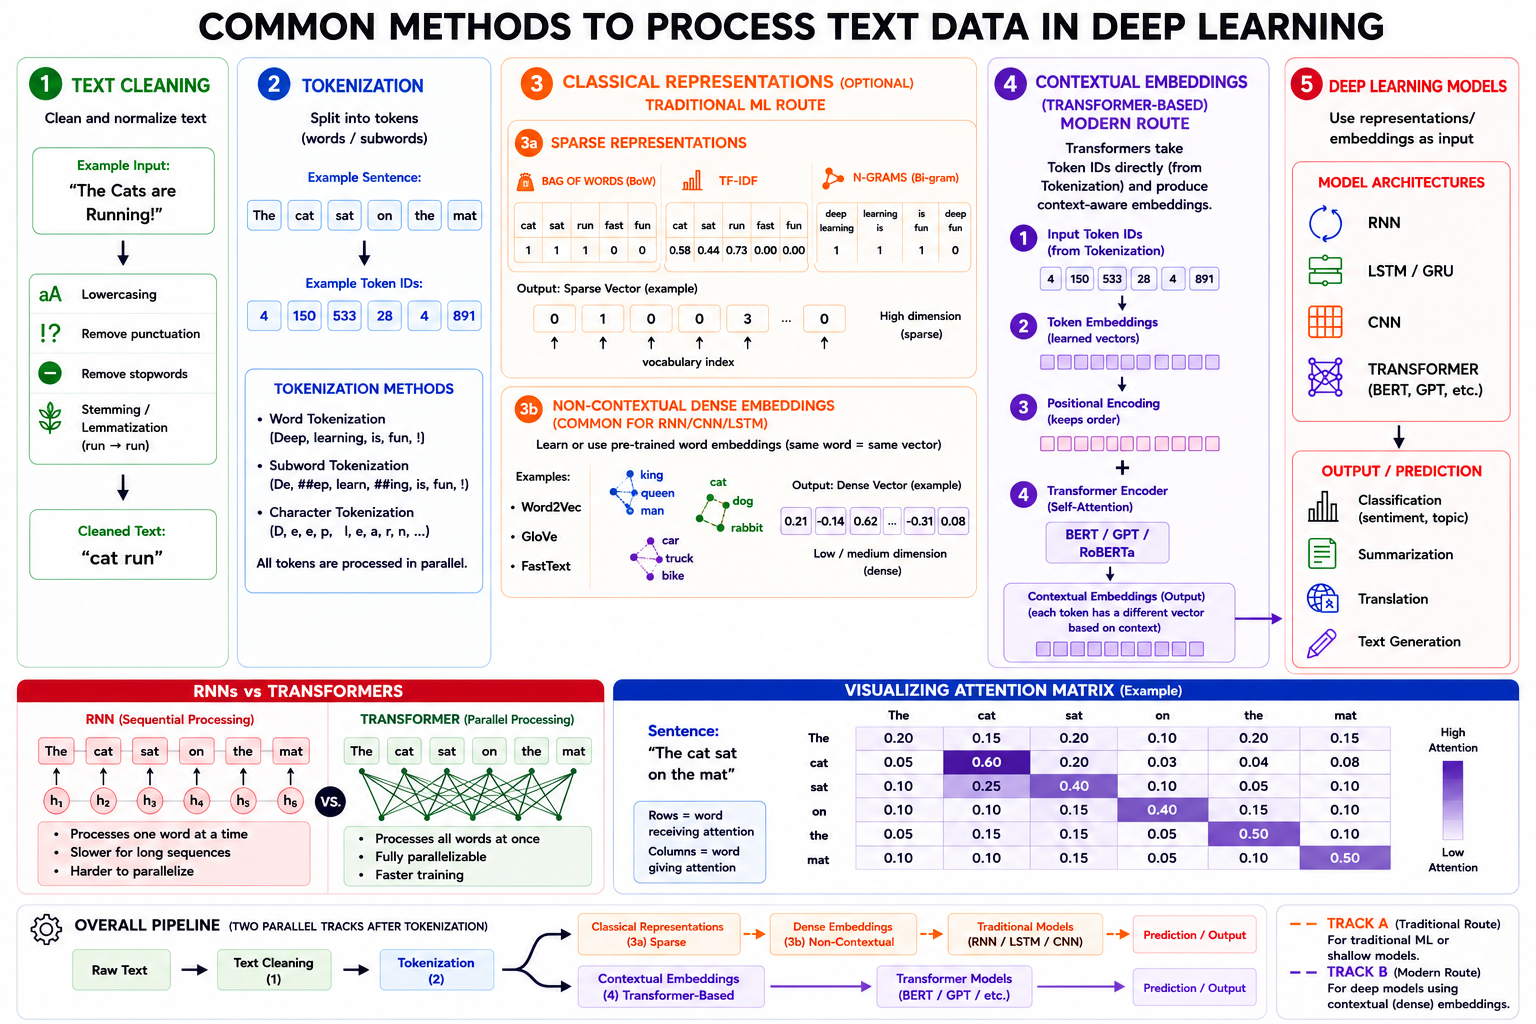


**Image Data vs Text Data for Deep Learning**

This image highlights the key difference between images and text. Images are spatial grids, while text is an ordered sequence of tokens. This is why image models often focus on spatial patterns, while text models must preserve token order and context.

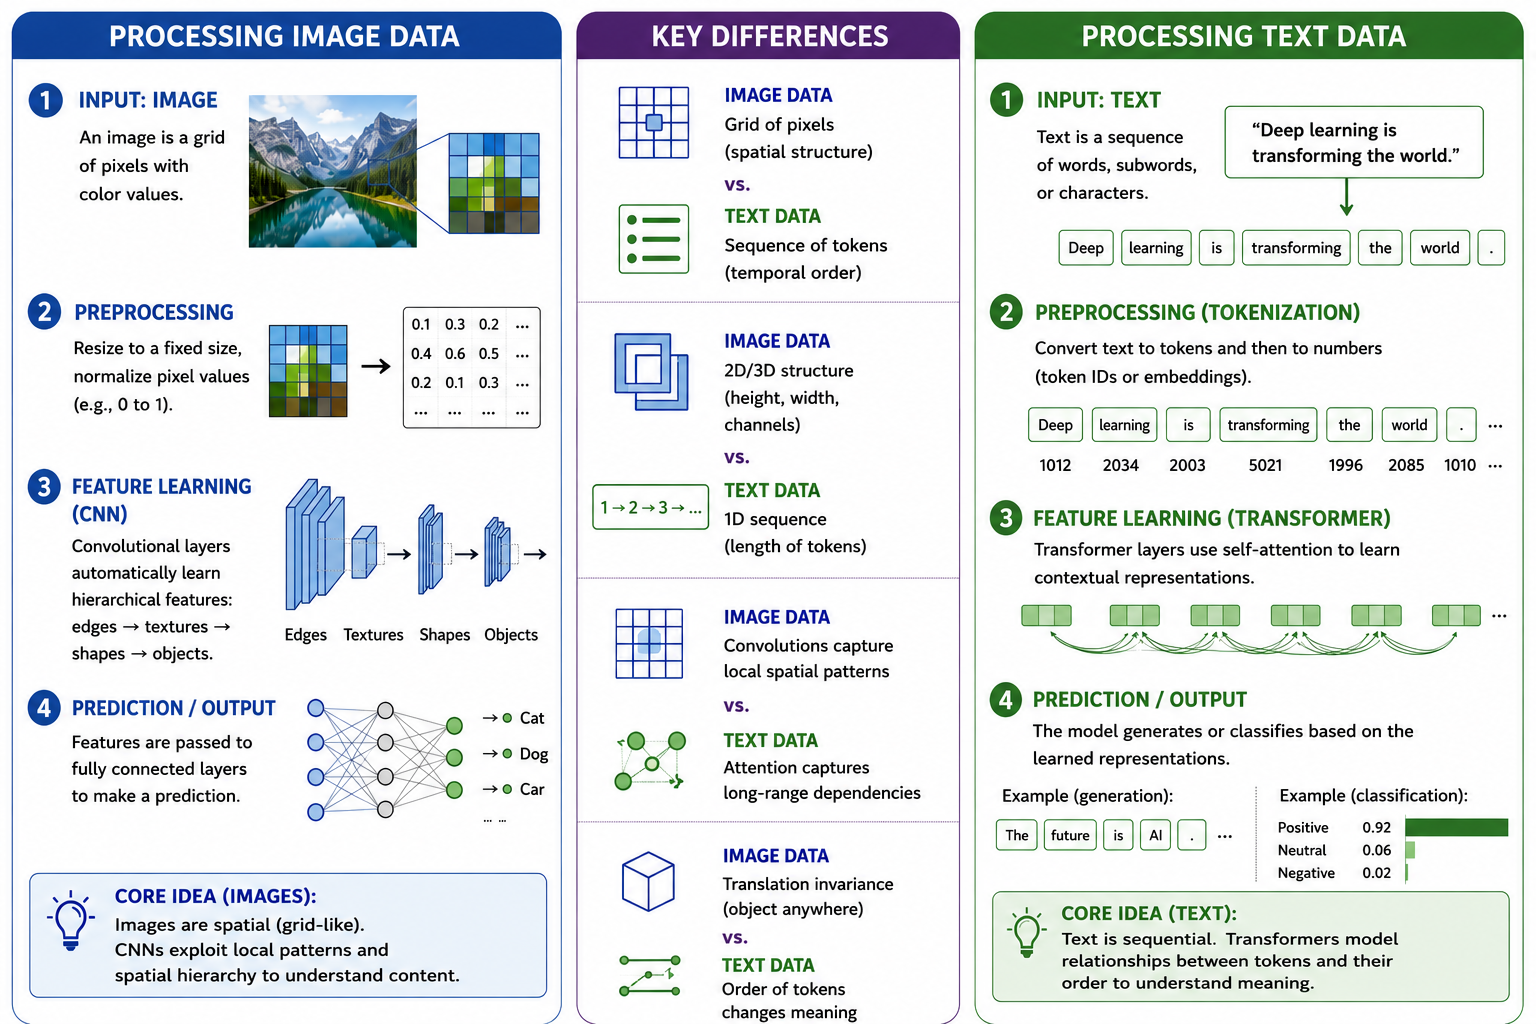



## **Table of Contents**

1. [Objectives](#toc-objectives)
2. [Setup](#toc-setup)
    1. [Installing Required Libraries](#toc-installing-required-libraries)
    2. [Importing Required Libraries](#toc-importing-required-libraries)
3. [Background](#toc-background)
4. [The i.i.d. Assumption](#toc-the-i-i-d-assumption)
5. [Understanding Sequential Modeling](#toc-understanding-sequential-modeling)
6. [Forms of Sequential Data](#toc-forms-of-sequential-data)
    1. [Working with time-series data](#toc-working-with-time-series-data)
    2. [Working with text data](#toc-working-with-text-data)
    3. [Exercise A - Import data set](#toc-exercise-a-import-data-set)
    4. [Exercise B - Extract audio clips](#toc-exercise-b-extract-audio-clips)
    5. [Exercise C - Plotting audio files](#toc-exercise-c-plotting-audio-files)
    6. [Exercise D - Basic pre-processing](#toc-exercise-d-basic-pre-processing)
    7. [Exercise E - Spectrogram](#toc-exercise-e-spectrogram)
    8. [Exercise A: Load human DNA data](#toc-exercise-a-load-human-dna-data)
    9. [Exercise B: Sequence of Characters to K-mers](#toc-exercise-b-sequence-of-characters-to-k-mers)
    10. [Exercise C: Bag-of-Words](#toc-exercise-c-bag-of-words)
    11. [Exercise D: Multinomial Naïve Bayes Classifier](#toc-exercise-d-multinomial-naive-bayes-classifier)


## **Objectives** <a id="toc-objectives"></a>

After completing this lab you will be able to:

*   Describe various forms of sequential data, and common tasks that can be modeled using sequential data
*   Decompose a time-series and perform time-series imputation
*   Pre-process and vectorize a text dataset
*   Pre-process and visualize an audio dataset, and create spectrograms


***


## **Setup** <a id="toc-setup"></a>


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### **Installing Required Libraries** <a id="toc-installing-required-libraries"></a>

The following required libraries are pre-installed in the Skills Network Labs environment. However, if you run these notebook commands in a different Jupyter environment (like Watson Studio or Ananconda), you will need to install these libraries by removing the `#` sign before `!mamba` in the following code cell.


In [618]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
# !mamba install -qy pandas==1.3.4 numpy==1.21.4 seaborn==0.9.0 matplotlib==3.5.0 scikit-learn==0.20.1
# Note: If your environment doesn't support "!mamba install", use "!pip install"

The following required libraries are **not** pre-installed in the Skills Network Labs environment. **You will need to run the following cell** to install them:


%%capture

!pip install nltk 

In [619]:
%%capture
import tensorflow as tf

tf.compat.v1.enable_eager_execution()

### **Importing Required Libraries** <a id="toc-importing-required-libraries"></a>

*We recommend you import all required libraries in one place (here):*


In [620]:
%%capture
# Hide import output and deprecation warnings to keep the notebook clean.
import os
import pathlib
import re
import string
import warnings

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.simplefilter('ignore')

import keras
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import skillsnetwork
import tensorflow as tf
from dateutil.parser import parse
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import sent_tokenize, word_tokenize
from scipy import signal
from scipy.io import wavfile
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
from sklearn.model_selection import ShuffleSplit, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeRegressor
from statsmodels.tsa.seasonal import seasonal_decompose

%matplotlib inline

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('omw-1.4')

print(tf.__version__)

# Force TensorFlow to use CPU in shared environments where GPU setup may vary.
tf.config.set_visible_devices([], "GPU")

sns.set_context('notebook')
sns.set_style('white')

## **Background** <a id="toc-background"></a>

In many machine learning problems, it is commonly assumed that the data are independently and identically distributed (i.i.d.). This means that each sample is generated independently and does not depend on previous samples.

However, this assumption is often violated when working with sequential or time series data, where current observations depend on past information.

For example:
- In weather prediction, today's weather is influenced by the weather from previous days. It is unlikely to snow immediately after an extremely hot day.
- In financial time series, stock prices are influenced not only by company fundamentals, but also by previous stock prices and market trends.

Many methods have been developed to analyze time series data. In this section, we will first study several classical time series methods. These approaches are important foundations for more advanced sequence models such as Recurrent Neural Networks (RNNs), which are specifically designed to model sequential dependencies in data.

## **The i.i.d. Assumption** <a id="toc-the-i-i-d-assumption"></a>



Many machine learning methods assume that data are independently and identically distributed (i.i.d.). This means that each sample is generated independently and does not depend on previous samples.

However, this assumption is often violated in sequential data, where neighboring observations are related to one another. In sequential datasets, current values may depend on past values, so the order of the data becomes important.

Examples of sequential data include:
- time series data,
- financial market prices,
- speech signals,
- and natural language sentences.

For example, in a part-of-speech tagging task:

$$
x_i = \text{``do you want fries''}
$$

$$
y_i = \text{verb pronoun verb noun}
$$

The goal is to learn a model that labels each word with its grammatical category::

$$
y = h(x)
$$

that predicts an output sequence $y$ from an input sequence $x$. 

So the model is learning:
Sentence  →  grammatical labels

In many sequential learning problems, the task is to predict the next element in a sequence based on previous observations:

$$
(y_1, y_2, ..., y_t) \rightarrow y_{t+1}
$$

Because sequential data contains dependencies between observations, specialized methods are often needed to model these relationships effectively. In this section, we will explore examples of non-i.i.d. data using financial time series from energy companies.

Let us walk through an example to highlight the issues when working with non-i.i.d. data. We will be using financial quotations from various energy companies.


* This uses IBM’s helper to download & unzip the financial dataset.
* `await` means: “wait until the download finishes before running the next lines”.

In [ ]:
await skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/financial-data.zip",
    overwrite=True,
)

  0%|          | 0/12 [00:00<?, ?it/s]

Saved to '.'


In [ ]:
import pandas as pd

symbols = {
    "TOT": "Total",
    "XOM": "Exxon",
    "CVX": "Chevron",
    "COP": "ConocoPhillips",
    "VLO": "Valero Energy",
}
template_name = "./financial-data/{}.csv"

quotes = {}
for symbol in symbols:
    data = pd.read_csv(
        template_name.format(symbol), index_col=0, parse_dates=True
    )
    quotes[symbols[symbol]] = data["open"]
quotes = pd.DataFrame(quotes)
quotes.head()

,Total,Exxon,Chevron,ConocoPhillips,Valero Energy
date,,,,,
2003-01-02,71.62,35.00,67.20,48.80,37.04
2003-01-03,72.12,35.25,67.82,49.53,38.13
2003-01-06,72.93,35.45,68.34,49.50,37.37
2003-01-07,72.40,36.05,69.75,49.85,37.46
2003-01-08,69.51,35.15,68.46,48.44,36.51


Let us plot a few financial quotations.


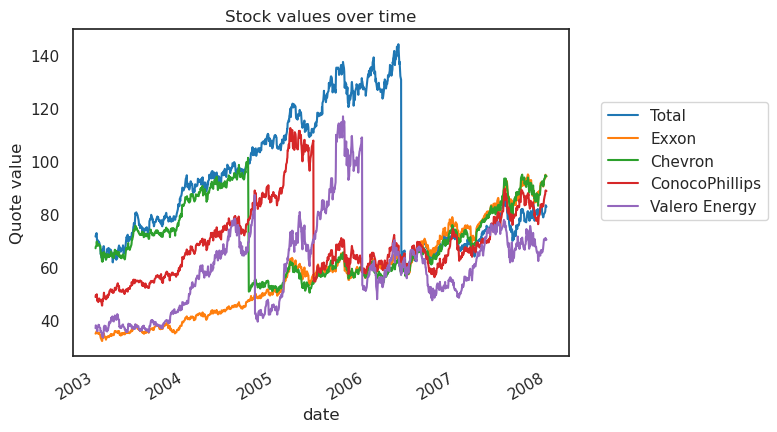

In [623]:
import matplotlib.pyplot as plt

quotes.plot()
plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Stock values over time")

We want to predict the quotation of Chevron using all other energy companies’ quotes. We will use the decision tree regressor that is expected to overfit and thus not generalize to unseen data. We will start off by splitting our data into a testing and training set.


In [ ]:
data, target = quotes.drop(columns=["Chevron"]), quotes["Chevron"]
data_train, data_test, target_train, target_test = train_test_split(
    data, target, shuffle=True, random_state=0
)

we have our features


In [625]:
data

,Total,Exxon,ConocoPhillips,Valero Energy
date,,,,
2003-01-02,71.62,35.00,48.80,37.04
2003-01-03,72.12,35.25,49.53,38.13
2003-01-06,72.93,35.45,49.50,37.37
2003-01-07,72.40,36.05,49.85,37.46
2003-01-08,69.51,35.15,48.44,36.51
...,...,...,...,...
2007-12-24,80.55,93.51,87.02,70.42
2007-12-26,81.10,93.66,87.68,70.92
2007-12-27,82.35,94.94,88.92,71.10


and target Chevron


In [626]:
target

date
2003-01-02    67.20
2003-01-03    67.82
2003-01-06    68.34
2003-01-07    69.75
2003-01-08    68.46
              ...  
2007-12-24    93.63
2007-12-26    94.31
2007-12-27    94.80
2007-12-28    94.38
2007-12-31    94.37
Name: Chevron, Length: 1258, dtype: float64

Let’s now define our model:


In [627]:
regressor = DecisionTreeRegressor()

In [ ]:
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
# Affect the index of `target_predicted` to ease the plotting
target_predicted = pd.Series(target_predicted, index=target_test.index)
target_predicted

date
2003-01-09    68.78
2004-12-17    52.57
2003-03-19    65.83
2006-11-29    70.46
2003-09-29    72.20
              ...  
2005-12-14    59.28
2006-12-22    72.64
2006-08-30    67.42
2004-10-28    53.50
2006-08-15    67.50
Length: 315, dtype: float64

Now we perform evaluation.


In [629]:
from sklearn.metrics import r2_score

test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: 0.83


We get outstanding generalization performance in terms of $R^2$. Let's plot the predictions against the ground truth.


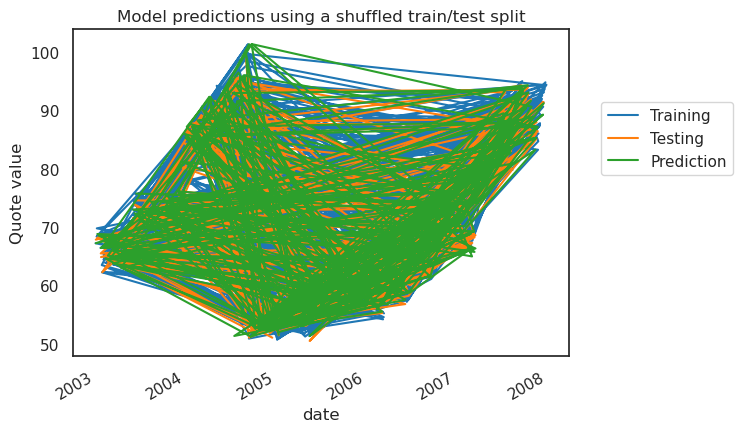

In [630]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a shuffled train/test split")

The results are surprisingly very good, as we had originally expected the model to overfit and not generalize on unseen test sets. Let us now investigate why this is the case.

In the previous split, `train_test_split` used its default behavior, `shuffle=True`. This randomly mixed dates before separating the data into training and testing sets. For time-series data, that can give an overly optimistic result because the training set may contain observations that occur after some of the test observations.

Next, we repeat the same modeling steps with `shuffle=False`. This keeps the original date order: the model trains on the earlier part of the series and tests on the later part. The purpose is to compare a random split with a time-ordered split and show why preserving sequence order gives a more realistic evaluation for forecasting-style problems.


In [ ]:
data_train, data_test, target_train, target_test = train_test_split(
    data,
    target,
    shuffle=False,
    random_state=0,
)
regressor.fit(data_train, target_train)
target_predicted = regressor.predict(data_test)
target_predicted = pd.Series(target_predicted, index=target_test.index)

In [632]:
test_score = r2_score(target_test, target_predicted)
print(f"The R2 on this single split is: {test_score:.2f}")

The R2 on this single split is: -2.07


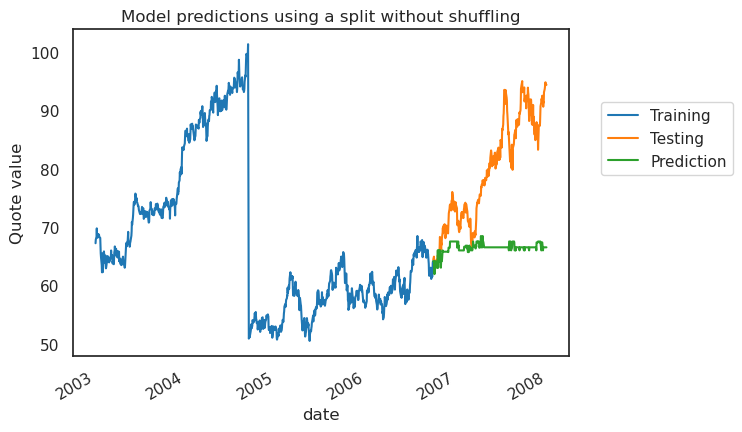

In [633]:
target_train.plot(label="Training")
target_test.plot(label="Testing")
target_predicted.plot(label="Prediction")

plt.ylabel("Quote value")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
_ = plt.title("Model predictions using a split without shuffling")

Now we see that the model performs much worse when it must predict later observations from earlier ones. Why is that?


Stock prices are time-series data, so the order of the rows matters. Prices from one day are usually similar to prices from nearby days. For example, the price on Tuesday is often close to the price on Monday and Wednesday. This means each row is not fully independent from the rows around it.

If we shuffle the rows before splitting the data, the training set and test set can contain dates that are very close to each other. The model may then get a high score because it has already trained on prices from nearby dates, not because it learned how to predict the future. This problem is called temporal leakage: information from the future, or from dates too close to the test period, accidentally helps the model during training.

By setting `shuffle=False`, we keep the dates in their original order. The model trains on the earlier part of the series and tests on the later part. This is a more realistic setup because forecasting usually means using past data to predict future data.


## **Understanding Sequential Modeling** <a id="toc-understanding-sequential-modeling"></a>



Sequential modeling is the process of learning patterns from ordered data and using past observations to predict future values or outputs. Unlike standard machine learning problems, sequential modeling takes the order of the data into account because current observations often depend on previous ones.

One common example is time series forecasting. For instance, a patient's physiological signals, such as heart rate, ECG, breathing rate, and body temperature, change over time. A sequential model can use these past measurements to predict the patient's future medical condition or disease progression.


Another important example is text prediction. Given a sequence of words or phrases, the model predicts the next word based on the previous context. Modern language models, such as chatbots and text generators, are built on this type of sequential modeling.

## **Forms of Sequential Data** <a id="toc-forms-of-sequential-data"></a>

Sequential data consists of elements arranged in a specific order, where the relationship between neighboring elements is important. Examples of sequential data include:
- time series data, such as stock prices or sensor measurements,
- gene sequences, such as $\{C, G, A, T\}$,
- speech signals,
- text sequences, such as letters, words, or numbers,
- video clips,
- and musical notes.

A key characteristic of sequential data is that the observations are not independent. Earlier elements in the sequence often influence later elements. In addition, sequences can have different lengths.

Many machine learning tasks can be modeled using sequential data, including:
- text classification, such as detecting spam emails,
- language translation, such as translating French to English,
- and time-series forecasting, such as predicting future stock prices.

In the following sections, we will examine several common types of sequential datasets and discuss the preprocessing techniques used for each.

### **Working with time-series data** <a id="toc-working-with-time-series-data"></a>


Time series data is a type of sequential data where values are recorded over time. Examples include daily temperatures, stock prices, heart rate measurements, and monthly sales.

A time series can be written as:

$$
X_1, X_2, X_3, \dots
$$

where each value is associated with a specific time point.

Unlike standard machine learning datasets, time-series observations are often related to one another. For example, today's stock price may depend on yesterday's price. In addition, the statistical properties of the data may change over time due to trends, seasonal effects, or unexpected events.

Because of this, time-series data usually does not satisfy the i.i.d. (independent and identically distributed) assumption commonly used in machine learning.


#### **Time-series decomposition**


Time series data often contains several underlying patterns. Time-series decomposition separates the data into different components to make these patterns easier to understand and analyze.

The main components are trend, seasonality, and cyclic patterns.

*   **trend**: A trend represents the long-term upward or downward movement in the data.

    For example:
    - increasing company sales over several years,
    - or decreasing temperatures during winter.


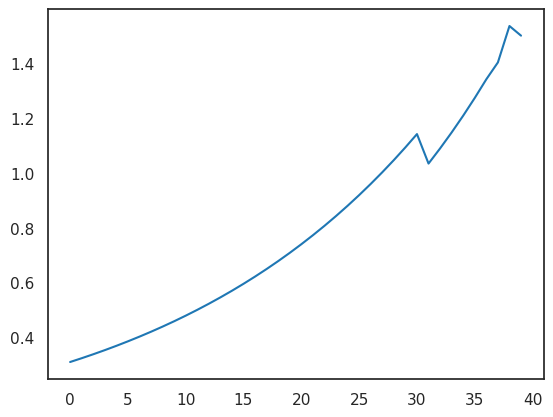

In [ ]:
trend = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/guinearice.csv",
    parse_dates=["date"],
    index_col="date",
)
plt.plot(trend.values)

*   **seasonality**: Seasonality refers to patterns that repeat at regular time intervals.

    Examples include:

    - higher retail sales during holidays,
    - daily temperature changes,
    - or increased traffic during weekday rush hours.

    These patterns occur at fixed and predictable intervals.

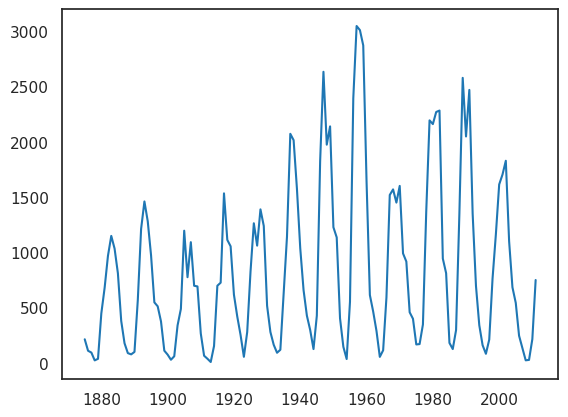

In [ ]:
seasonality = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/sunspotarea.csv",
    parse_dates=["date"],
    index_col="date",
)
plt.plot(seasonality.value)

A time series can have both trend and seasonality, for example:


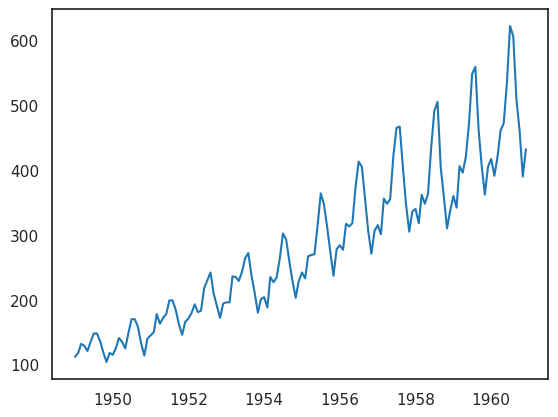

In [ ]:
seasonality_trend = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/AirPassengers.csv",
    parse_dates=["date"],
    index_col="date",
)
plt.plot(seasonality_trend.value)

*   **cyclic**: Cyclic patterns are similar to seasonality, but they do not occur at fixed intervals.

    For example:

    - economic growth and recession cycles,
    - or changes in stock markets over several years.

    Unlike seasonality, cyclic patterns may vary in length and timing.

Time series data can often be modeled using either an **additive model** or a **multiplicative model**. In both cases, the observed value is described using components such as trend, seasonality, and random error.

**Additive Time Series Model**

In an additive model, the components are added together:

$$
Value(t) = BaseLevel(t) + Trend(t) + Seasonality(t) + Error(t)
$$

This model is commonly used when the seasonal variation remains approximately constant over time.

For example:

- retail sales increasing by about 100 units every holiday season,
- regardless of the overall sales level.


**Multiplicative Time Series Model**

In a multiplicative model, the components are multiplied together:

$$
Value(t) = BaseLevel(t) \times Trend(t) \times Seasonality(t) \times Error(t)
$$

This model is used when the seasonal variation changes proportionally with the data level.

For example:

- sales increasing by 20% during the holiday season,
- where the size of the increase depends on the current sales level.

We can use functions like `seasonal_decompose` from the python package, `statsmodel`, to decompose our time-series into trend, seasonality, and the residual components.


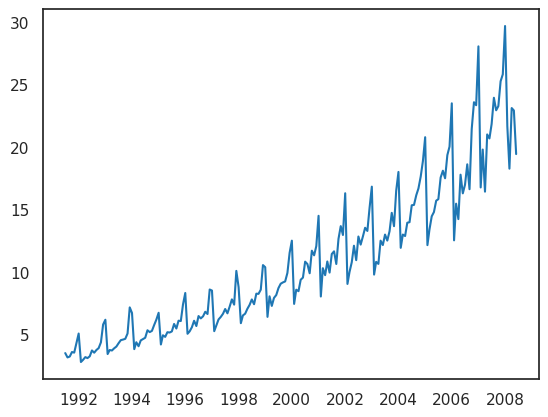

In [ ]:
# Import Data
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/a10.csv",
    parse_dates=["date"],
    index_col="date",
)
plt.plot(df.value)

Let us start by performing additive decomposition. Note that by using `extrapolate_trend = 'freq'`, we impute missing values at the beginning of the time series.


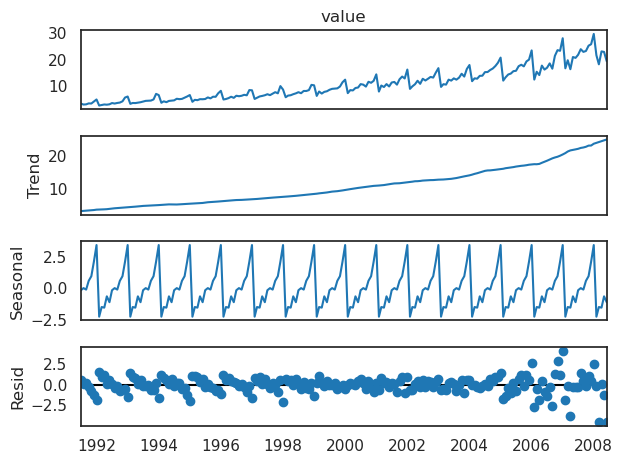

In [ ]:
# Additive Decomposition
result_add = seasonal_decompose(
    df["value"], model="additive", extrapolate_trend="freq"
)

# Plot
result_add.plot()
plt.show()

The additive residual plot shows a pattern, especially larger errors when the series is higher, additive decomposition is not explaining the data very well.

Now, similarly we can try performing multiplicative decomposition:


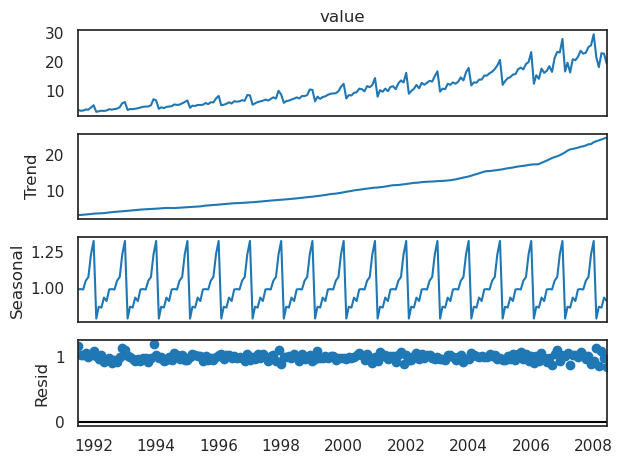

In [ ]:
# Multiplicative Decomposition
result_mul = seasonal_decompose(
    df["value"], model="multiplicative", extrapolate_trend="freq"
)

# Plot
result_mul.plot()
plt.show()

The multiplicative residual plot looks more stable around 1, with less obvious structure, multiplicative is a better fit.

So how do we detrend our time series? One way would be to subtract the trend component obtained from the time series decomposition we saw earlier.


Text(0.5, 1.0, 'Drug Sales detrended by subtracting the trend component')

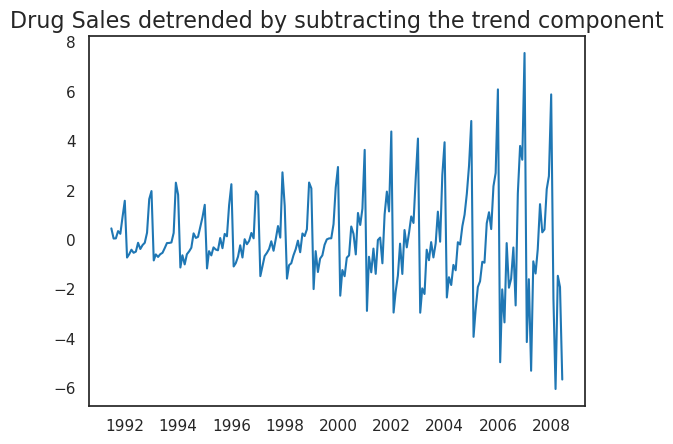

In [ ]:
detrended = df.value.values - result_mul.trend
plt.plot(detrended)
plt.title(
    "Drug Sales detrended by subtracting the trend component", fontsize=16
)

This plot helps us study the seasonal behavior separately from overall growth.
- the repeating seasonal pattern becomes easier to see,
- the data fluctuates around zero,
- seasonal fluctuations become larger over time,
- suggesting multiplicative seasonality rather than additive seasonality.

Similarly, we can remove the seasonality component:


Text(0.5, 1.0, 'Drug Sales deseasonalized by dividing by the seasonal component')

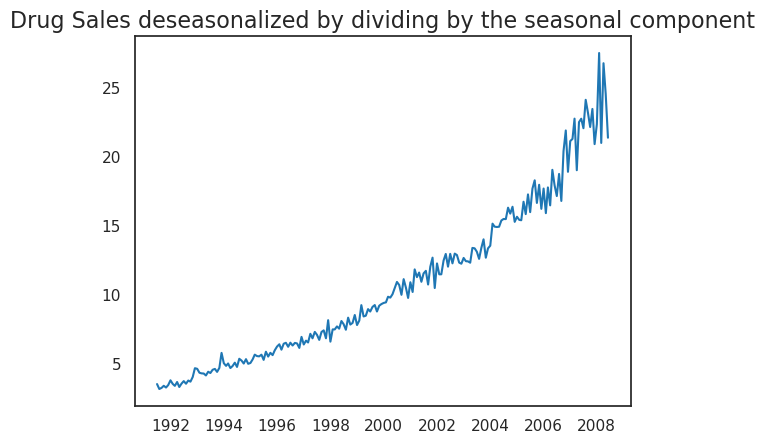

In [ ]:
deseasonalized = df.value.values / result_mul.seasonal

# Plot
plt.plot(deseasonalized)
plt.title(
    "Drug Sales deseasonalized by dividing by the seasonal component",
    fontsize=16,
)

This plot helps us focus on the overall trend without seasonal effects.
- the long-term upward trend becomes much clearer,
- periodic seasonal peaks are mostly removed,
- the underlying growth pattern is easier to analyze.

#### **Time-series imputation**



Time-series data may contain missing dates or missing observations. This can happen when data was not recorded, lost, or unavailable during certain time periods.

Several methods can be used to fill missing values, depending on the characteristics of the data.

**Forward Fill**

Forward fill replaces a missing value with the most recent previous value.This method is useful when values change slowly over time.


For example:

```text
10, 12, NaN, NaN, 15
```

becomes:

```text
10, 12, 12, 12, 15
```

**Backward Fill**

Backward fill replaces a missing value with the next available value.

For example:

```text
10, NaN, NaN, 15
```

becomes:

```text
10, 15, 15, 15
```


**Linear Interpolation**

Linear interpolation estimates missing values by drawing a straight line between neighboring observations. This method works well when the data changes smoothly over time.

For example:

```text
10, NaN, NaN, 16
```

becomes approximately:

```text
10, 12, 14, 16
```



Let us start by parsing the data frame indices as dates.


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/a10.csv",
    parse_dates=["date"],
    index_col="date",
)

*   **Forward Imputation**


<Axes: title={'center': 'Forward Fill (MSE: 0.0)'}, xlabel='date'>

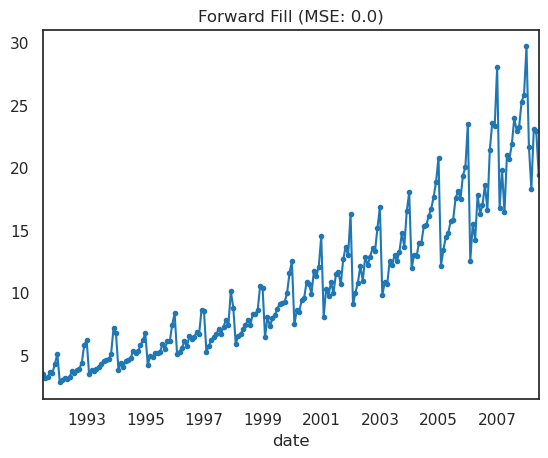

In [ ]:
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error

df_ffill = df.ffill()  # pandas forward fill method to impute missing values
# Print the MSE between imputed value and ground truth
error = np.round(mean_squared_error(df["value"], df_ffill["value"]), 2)
df_ffill["value"].plot(
    title="Forward Fill (MSE: " + str(error) + ")",
    label="Forward Fill",
    style=".-",
)

*   **Backward Imputation**


<Axes: title={'center': 'Backward Fill (MSE: 0.0)'}, xlabel='date'>

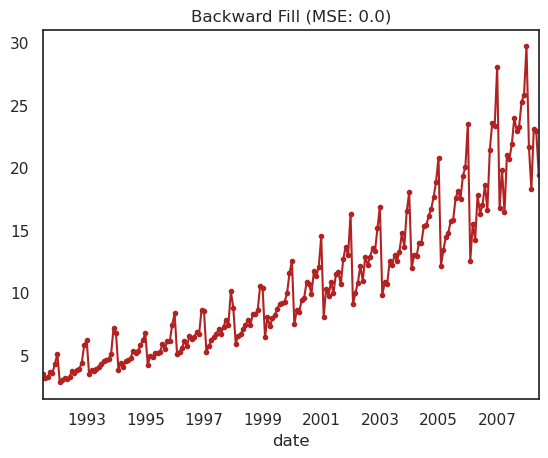

In [ ]:
df_bfill = df.bfill()  # pandas backward fill method to impute missing values
error = np.round(mean_squared_error(df["value"], df_bfill["value"]), 2)
df_bfill["value"].plot(
    title="Backward Fill (MSE: " + str(error) + ")",
    label="Back Fill",
    color="firebrick",
    style=".-",
)

*   **Linear Interpolation**


<Axes: title={'center': 'Linear Fill (MSE: 0.0)'}, xlabel='date'>

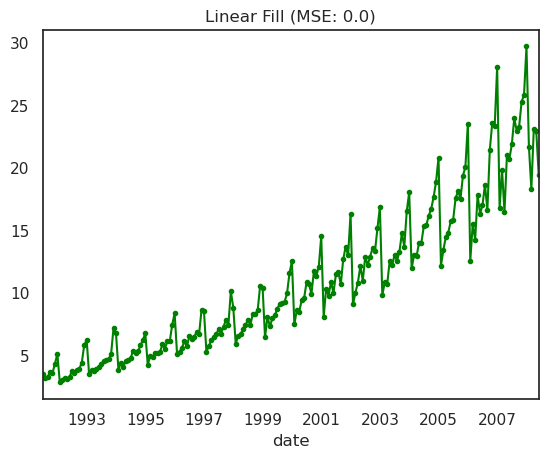

In [ ]:
df["rownum"] = np.arange(df.shape[0])
df_nona = df.dropna(subset=["value"])
f = interp1d(df_nona["rownum"], df_nona["value"])
df["linear_fill"] = f(df["rownum"])
error = np.round(mean_squared_error(df["value"], df["linear_fill"]), 2)
df["linear_fill"].plot(
    title="Linear Fill (MSE: " + str(error) + ")",
    label="Cubic Fill",
    color="green",
    style=".-",
)

Time-series decomposition and imputation are common pre-processing steps used when working on time-series prediction or forecasting tasks.


### **Working with text data** <a id="toc-working-with-text-data"></a>


In this section, we will be working with a portion of the [Twitter Sentiment Analysis](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) dataset from Kaggle.

> Given a message and an entity, the task is to judge the sentiment of the message about the entity. There are three classes in this dataset: Positive, Negative, and Neutral.

The file contains the tweet along with the labels. For the purpose of this lab, we will just explore the dataset, and perform some basic pre-processing.


First, let us download this dataset.


In [ ]:
cols = ["Id", "Entity", "Sentiment", "Tweet"]
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/twitter_validation.csv",
    names=cols,
    header=None,
)

In [647]:
df.head(2)

,Id,Entity,Sentiment,Tweet
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...


#### **Visualizing**


Using `groupby` in pandas, we can determine the number of tweets present in each category and plot them.


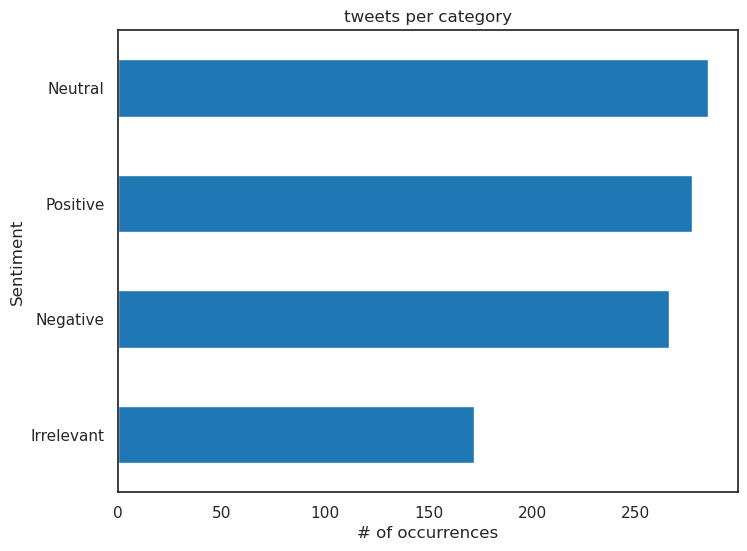

In [ ]:
fig = plt.figure(figsize=(8, 6))

df.groupby(["Sentiment"]).Tweet.count().sort_values().plot.barh(
    ylim=0, title="tweets per category"
)

plt.xlabel("# of occurrences", fontsize=12)

#### **Cleaning up**



Raw tweets are highly unstructured and often contain noisy or unnecessary information. Before applying machine learning or natural language processing (NLP) techniques, the text should be cleaned and standardized.


Most of the text data is cleaned by following the steps below.

*   **Remove punctuations** \
    Punctuation marks such as `.`, `,`, `!`, and `?` usually do not add useful semantic meaning for many NLP tasks and are often removed.

*   **Remove stopwords** \
    Stopwords are very common words that carry little meaningful information, such as:
    ```text
    the, a, is, from, and
    ```
*   **Tokenization** \
    Tokenization is the process of splitting a sentence into individual words or tokens.

    For example:

    ```text
    "I love NLP"
    ```

    becomes:

    ```python
    ["I", "love", "NLP"]
    ```
*   **Lemmatization and stemming** \
    Lemmatization and stemming convert different forms of a word into a simpler root form.

    Examples:

    ```text
    running → run
    studies → study
    ```

Using a corpus of stop-words, including articles, prepositions, and conjunctions, from the Natural Language Toolkit (NLTK) suite, words with little lexical content (such as the, a, also, from, and so on) can be filtered out, for more check out this <a href="https://realpython.com/nltk-nlp-python/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01">link</a>


In [ ]:
def remove_punctuation(text):
    regular_punct = list(string.punctuation)
    for punc in regular_punct:
        if punc in text:
            text = text.replace(punc, " ")
    return text.strip().lower()


df["Tweet"] = df["Tweet"].apply(remove_punctuation)

In [ ]:
def remove_stopwords(tweet):
    en_stops = set(stopwords.words("english"))
    tweet = tweet.split()
    tweet = " ".join([word for word in tweet if not word in en_stops])
    return tweet


df["Tweet"] = df["Tweet"].apply(remove_stopwords)

Tweets can be further processed with tokenization and lemmatization, both of which were performed using packages in the NLTK suite.

Tokenization converts text to analysis relevant word tokens, while lemmatization transforms words to a simpler form, returning the word’s lemma – a canonical form of all its inflectional forms (for example, go represents its inflected forms of goes, going, went, gone).


In [ ]:
df["Tweet"] = df["Tweet"].apply(word_tokenize)

In [ ]:
def lemma_wordnet(input):
    lem = WordNetLemmatizer()
    return [lem.lemmatize(w) for w in input]


df["Tweet"] = df["Tweet"].apply(lemma_wordnet)

In [ ]:
# combine individual words


def combine_text(input):
    combined = " ".join(input)
    return combined


df["Tweet"] = df["Tweet"].apply(combine_text)

In [654]:
df

,Id,Entity,Sentiment,Tweet
0,3364,Facebook,Irrelevant,mentioned facebook struggling motivation go ru...
1,352,Amazon,Neutral,bbc news amazon bos jeff bezos reject claim co...
2,8312,Microsoft,Negative,microsoft pay word function poorly samsungus c...
3,4371,CS-GO,Negative,csgo matchmaking full closet hacking truly awf...
4,4433,Google,Neutral,president slapping american face really commit...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ toronto art culture capital canada it ’ s w...
996,4359,CS-GO,Irrelevant,actually good move tot bring viewer one people...
997,2652,Borderlands,Positive,today sucked it ’ s time drink wine n play bor...
998,8069,Microsoft,Positive,bought fraction microsoft today small win


#### **Vectorization**



Machine learning models cannot work directly with raw text. Therefore, text data must be converted into numerical vectors before training a model. This process is called **text vectorization**.

In this section, we explore two common vectorization techniques:

- Bag-of-Words (BoW)
- Bi-Gram Bag-of-Words (B-BoW)

Both methods can be implemented using Scikit-learn’s `CountVectorizer`.

```python
CountVectorizer(ngram_range=(1,1))
```

is used for standard Bag-of-Words, while:

```python
CountVectorizer(ngram_range=(2,2))
```

is used for Bi-Gram Bag-of-Words.

**Bag-of-Words (BoW)**

Bag-of-Words converts text into fixed-length numerical vectors by counting how many times each word appears in a document.

For example:

```text
"I love NLP"
"I love machine learning"
```

may produce a vocabulary like:

```text
["I", "love", "NLP", "machine", "learning"]
```

Each document is then represented as a vector of word counts.

BoW ignores:

- word order,
- grammar,
- and semantic relationships between words.

It only considers word frequency.

**Bi-Gram Bag-of-Words (B-BoW)**

Bi-Gram Bag-of-Words extends BoW by using pairs of consecutive words instead of single words.

For example:

```text
"I love NLP"
```

becomes:

```text
["I love", "love NLP"]
```

Bi-grams capture more contextual information than standard BoW because they preserve short word sequences.

**Sparse Representation**

BoW methods often create very large and sparse matrices because most documents contain only a small fraction of the total vocabulary.

For datasets with thousands of unique words, preprocessing steps such as:

- removing stopwords,
- stemming,
- lemmatization,
- and punctuation removal

can help reduce vocabulary size and improve efficiency.

##### **Bag-of-Words (BoW)**
We can plot some of the values we see they are zero


In [ ]:
cv = CountVectorizer(ngram_range=(1, 1))
X_train_bow = cv.fit_transform(df["Tweet"])
print(X_train_bow[0:10, 0:10].todense())

[[0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [ ]:
cv = CountVectorizer(ngram_range=(1, 1))
X_train_bow = cv.fit_transform(df["Tweet"].values.tolist())
Y_train_bow = df["Sentiment"]
Y_train_bow

0      Irrelevant
1         Neutral
2        Negative
3        Negative
4         Neutral
          ...    
995    Irrelevant
996    Irrelevant
997      Positive
998      Positive
999       Neutral
Name: Sentiment, Length: 1000, dtype: object

##### **Bi-Gram Bag-of-Words (B-BoW)**
Bigram BoW (B-BoW) represents a text document as a weakly ordered collection of contiguous sequences but of two items. It allows for the preservation of more word locality information.


In [ ]:
cv_bbow = CountVectorizer(ngram_range=(2, 2))
X_train_bbow = cv_bbow.fit_transform(df["Tweet"])
Y_train_bbow = df["Sentiment"]
Y_train_bbow

0      Irrelevant
1         Neutral
2        Negative
3        Negative
4         Neutral
          ...    
995    Irrelevant
996    Irrelevant
997      Positive
998      Positive
999       Neutral
Name: Sentiment, Length: 1000, dtype: object

##### **TF-IDF**
Term frequency-inverse document frequency (TF-IDF) is a frequency-based embedding method that
measures the importance of a word in a given document (see notebook 4.6.1 for more details). It can be implemented using the `TfidfVectorizer` function from sklearn.


In [ ]:
vectorizer = TfidfVectorizer(use_idf=True, ngram_range=(1, 1))
vectorizer.fit(df)
X_train_tfidf = vectorizer.fit_transform(df["Tweet"])
Y_train_tfidf = df["Sentiment"]
Y_train_tfidf

0      Irrelevant
1         Neutral
2        Negative
3        Negative
4         Neutral
          ...    
995    Irrelevant
996    Irrelevant
997      Positive
998      Positive
999       Neutral
Name: Sentiment, Length: 1000, dtype: object

# **Example 1 - Working with Speech Commands**


In this example, we will walk through how to pre-process audio files in the .WAV format. We will be using a portion of the [Speech Commands dataset (Warden, 2018)](https://www.tensorflow.org/datasets/catalog/speech_commands), which contains short (one-second or less) audio clips of commands, such as "down", "go", "left", "no", "right", "stop", "up", and "yes".


### **Exercise A - Import data set** <a id="toc-exercise-a-import-data-set"></a>


Let us start by importing a portion of the Speech Commands dataset. The original dataset consists of over 105,000 audio files in the WAV (Waveform) audio file format of people saying 35 different words.


A portion of the dataset is provided by [Tensorflow](http://storage.googleapis.com/download.tensorflow.org/data/mini_speech_commands.zip?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) as a .zip file. We have modified it further to include just a few test files.


In [ ]:
await skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/datasets/mini_speech_commands.zip",
    overwrite=True,
)

  0%|          | 0/186 [00:00<?, ?it/s]

Saved to '.'


If you open up the data path, you will see that the dataset's audio clips are stored in eight folders corresponding to each speech command: no, yes, down, go, left, up, right, and stop.


### **Exercise B - Extract audio clips** <a id="toc-exercise-b-extract-audio-clips"></a>


Start off by listing the commands by reading the names of the eight folders that were created earlier.


In [ ]:
# Write your solution here:
data_dir = "mini_speech_commands"

<details>
    <summary>Click here for Solution</summary>

```python
commands = np.array(tf.io.gfile.listdir(str(data_dir)))
commands = commands[commands != './data/mini_speech_commands/README.md']
commands
```

</details>


Now we will extract the names/paths of the audio clips into a file:


In [ ]:
filenames = tf.io.gfile.glob(str(data_dir) + "/*/*")
filenames

['mini_speech_commands/go/.DS_Store',
 'mini_speech_commands/go/ffd2ba2f_nohash_2.wav',
 'mini_speech_commands/go/ffa76c4a_nohash_0.wav',
 'mini_speech_commands/go/ffd2ba2f_nohash_3.wav',
 'mini_speech_commands/left/.DS_Store',
 'mini_speech_commands/left/ffd2ba2f_nohash_2.wav',
 'mini_speech_commands/left/ffd2ba2f_nohash_1.wav',
 'mini_speech_commands/left/ffd2ba2f_nohash_4.wav',
 'mini_speech_commands/yes/.DS_Store',
 'mini_speech_commands/yes/ff21fb59_nohash_0.wav',
 'mini_speech_commands/yes/ffd2ba2f_nohash_0.wav',
 'mini_speech_commands/yes/ffd2ba2f_nohash_2.wav',
 'mini_speech_commands/yes/fe1916ba_nohash_1.wav',
 'mini_speech_commands/right/.DS_Store',
 'mini_speech_commands/right/ffbb695d_nohash_0.wav',
 'mini_speech_commands/right/ffd2ba2f_nohash_1.wav',
 'mini_speech_commands/right/ffd2ba2f_nohash_4.wav',
 'mini_speech_commands/stop/.DS_Store',
 'mini_speech_commands/stop/fffcabd1_nohash_1.wav',
 'mini_speech_commands/stop/ffbb695d_nohash_0.wav',
 'mini_speech_commands/stop/f

Print out the number of audio clips present.


In [662]:
# Write your solution here
len(filenames)

83

### **Exercise C - Plotting audio files** <a id="toc-exercise-c-plotting-audio-files"></a>


Let's plot an audio waveforms by converting it to a numpy array. We will first pick a test file.


In [ ]:
from scipy.io.wavfile import read

test_file_name = "/no/97f4c236_nohash_3.wav"

Now use the `read` function from `scipy.io.wavfile` to read in the wav file as an array.


In [ ]:
# Write your solution here
rate, test_file = read(data_dir + test_file_name)

Plot the test file.


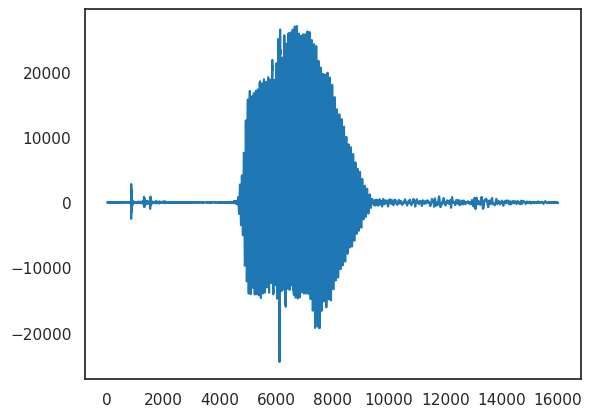

In [665]:
# Write your solution here
plt.plot(test_file)

### **Exercise D - Basic pre-processing** <a id="toc-exercise-d-basic-pre-processing"></a>


In this section, we will learn how to preprocess audio clips for machine learning tasks.

A `.wav` file stores raw audio data together with information about the audio format.

It typically contains:

- **Audio samples**: numerical values representing the sound wave over time, positive values → air pressure above normal, negative values → air pressure below normal, zero → silence.
- **Sampling rate**: the number of samples recorded per second,
- **Channels**: mono (`1`) or stereo (`2`) audio,
- **Bit depth**: the precision used to store each audio sample.

For example, a sampling rate of `16 kHz` means:

$$
16,000
$$

audio samples are recorded every second.


#### **Decoding WAV Files**

We will use TensorFlow’s `tf.audio.decode_wav` function to read and decode the audio files into tensors.

```python
tf.audio.decode_wav()
```

The original audio data is stored as signed 16-bit integers ranging from:

```text
-32768 to 32767
```

After decoding, TensorFlow automatically converts these values into floating-point numbers scaled between:

```text
-1.0 to 1.0
```

This format is easier to process in machine learning models.

#### **Output Tensor Shape**

The tensor returned by `tf.audio.decode_wav` has the shape:

```python
[samples, channels]
```

where:

- `samples` represents the number of audio time points,
- and `channels` represents the number of audio channels.

For example:

- `1` channel = mono audio,
- `2` channels = stereo audio.

The Speech Commands dataset contains only mono recordings, so the number of channels is always `1`.

We will first start by reading the test file as a tensor object.


In [ ]:
test_file_tensor = tf.io.read_file(data_dir + "/no/97f4c236_nohash_3.wav")

In [667]:
# Write your solution here
test_audio, _ = tf.audio.decode_wav(contents=test_file_tensor)
print(test_audio.shape)

(16000, 1)


### **Exercise E - Spectrogram** <a id="toc-exercise-e-spectrogram"></a>


Waveforms in this dataset are represented in the time domain.

Let us look into transforming the waveforms from the time-domain signals into the time-frequency-domain signals by converting it to a spectrogram. A spectrogram shows frequency changes over time and can be represented as 2D images. These images can even be used as input to a neural network.

We will use the `spectrogram` function from `scipy` to do this.


In [668]:
frequencies, times, spectrogram = signal.spectrogram(test_file, rate)

Use the `pcolormesh` and `imshow` functions with time, frequencies, and spectrogram as input to plot the spectrogram.


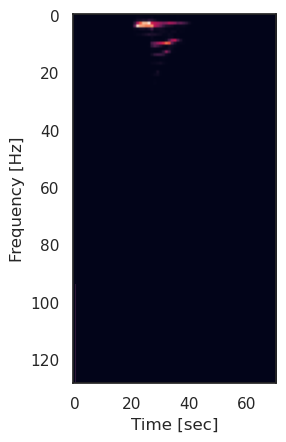

In [ ]:
# Write your solution here
plt.pcolormesh(times, frequencies, spectrogram)
plt.imshow(spectrogram)
plt.ylabel("Frequency [Hz]")
plt.xlabel("Time [sec]")
plt.show()

# **Example 2 - Gene Family Classification**


In this example, we will train a Naïve Bayes (NB) classifier on a human DNA sequence dataset to predict the gene family class label. The dataset contains seven different classes shown in the table below.


| gene family                   | number | class label |
| ----------------------------- | ------ | ----------- |
| *G-protein coupled receptors* | 531    | 0           |
| *Tyrosine kynase*             | 534    | 1           |
| *Tyrosine phosphatase*        | 349    | 2           |
| *Synthetase*                  | 672    | 3           |
| *Synthase*                    | 711    | 4           |
| *Ion channel*                 | 240    | 5           |
| *Transcription factor*        | 1343   | 6           |


### **Exercise A: Load human DNA data** <a id="toc-exercise-a-load-human-dna-data"></a>


In [ ]:
await skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML311-Coursera/labs/Module4/L1/human_data.txt",
    overwrite=True,
)

Saved to '.'


Let us start by reading the tab-separated `human_data.txt` file using Pandas.


In [ ]:
# Write your solution here
human_data = pd.read_csv("human_data.txt", sep="\t")

In [672]:
human_data.head()

,sequence,class
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3


Next, we will create a plot to view the class distribution in our data.


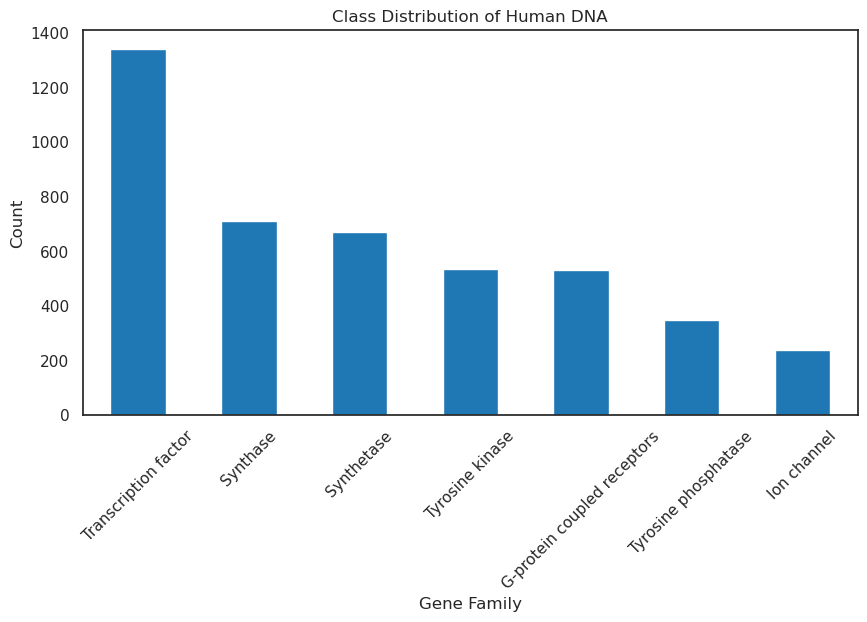

In [ ]:
# Mapping from class labels to gene family names
gene_family = {
    0: "G-protein coupled receptors",
    1: "Tyrosine kinase",
    2: "Tyrosine phosphatase",
    3: "Synthetase",
    4: "Synthase",
    5: "Ion channel",
    6: "Transcription factor",
}

# Create a new column with gene family names
human_data["gene_family"] = human_data["class"].map(gene_family)

# Plot class distribution
human_data["gene_family"].value_counts().plot.bar(figsize=(10, 5))

plt.title("Class Distribution of Human DNA")
plt.xlabel("Gene Family")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

### **Exercise B: Sequence of Characters to K-mers** <a id="toc-exercise-b-sequence-of-characters-to-k-mers"></a>


Most machine learning models for classification and regression require inputs to have a consistent numerical representation. For biological sequence analysis, one common approach is to split long DNA or protein sequences into smaller overlapping fragments called **k-mers**.

A **k-mer** is a substring of length `k` extracted from a sequence.

For example, consider the DNA sequence:

```text
GTGCCCAGGT
```

If we choose:

```text
k = 3
```

the sequence is converted into overlapping 3-mer words:

```text
GTG
TGC
GCC
CCC
CCA
CAG
AGG
GGT
```

Each k-mer is created by moving one position at a time along the sequence.

These k-mer fragments can then be treated similarly to words in natural language processing (NLP), allowing machine learning models to analyze biological sequences more effectively.

In [ ]:
def kmers_funct(seq, size=6):
    return [seq[x : x + size].lower() for x in range(len(seq) - size + 1)]

If we feed our sequence of length 10 to this function, we get the following 5 k-mers.


In [ ]:
kmers_funct("GTGCCCAGGT")

['gtgccc', 'tgccca', 'gcccag', 'cccagg', 'ccaggt']

Now, use the `apply()` to apply this function to the entire `human_data`.


In [ ]:
# Write your solution here
human_data["words"] = human_data["sequence"].apply(kmers_funct)
human_data.head()

,sequence,class,gene_family,words
0,ATGCCCCAACTAAATACTACCGTATGGCCCACCATAATTACCCCCA...,4,Synthase,"[atgccc, tgcccc, gcccca, ccccaa, cccaac, ccaac..."
1,ATGAACGAAAATCTGTTCGCTTCATTCATTGCCCCCACAATCCTAG...,4,Synthase,"[atgaac, tgaacg, gaacga, aacgaa, acgaaa, cgaaa..."
2,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,Synthetase,"[atgtgt, tgtgtg, gtgtgg, tgtggc, gtggca, tggca..."
3,ATGTGTGGCATTTGGGCGCTGTTTGGCAGTGATGATTGCCTTTCTG...,3,Synthetase,"[atgtgt, tgtgtg, gtgtgg, tgtggc, gtggca, tggca..."
4,ATGCAACAGCATTTTGAATTTGAATACCAGACCAAAGTGGATGGTG...,3,Synthetase,"[atgcaa, tgcaac, gcaaca, caacag, aacagc, acagc..."


To clean up the resulting dataset, we will drop the `sequence` column.

Let us view the first 5 rows.


In [ ]:
human_data = human_data.drop("sequence", axis=1)
human_data.head()

,class,gene_family,words
0,4,Synthase,"[atgccc, tgcccc, gcccca, ccccaa, cccaac, ccaac..."
1,4,Synthase,"[atgaac, tgaacg, gaacga, aacgaa, acgaaa, cgaaa..."
2,3,Synthetase,"[atgtgt, tgtgtg, gtgtgg, tgtggc, gtggca, tggca..."
3,3,Synthetase,"[atgtgt, tgtgtg, gtgtgg, tgtggc, gtggca, tggca..."
4,3,Synthetase,"[atgcaa, tgcaac, gcaaca, caacag, aacagc, acagc..."


As shown above, each DNA sequence has been converted to lowercase and split into overlapping k-mers of length 6.

For example:

```text
gtgcccaggt
```

becomes:

```text
gtgccc
tgccca
gcccag
cccagg
ccaggt
```

We then combine these k-mers into a single text string, similar to forming a sentence in natural language processing (NLP).

For example:

```text
"gtgccc tgccca gcccag cccagg ccaggt"
```

Each k-mer acts like a word in a sentence.

We do this because machine learning models cannot directly understand raw DNA sequences. The sequences must first be converted into numerical features.

By treating k-mers as words, we can apply NLP techniques such as Bag-of-Words (BoW) to count how frequently each k-mer appears in a sequence. This converts DNA sequences into numerical feature vectors that can be used by machine learning models for classification and prediction tasks.

K-mers are useful because important biological information is often contained in short local sequence patterns.

In [ ]:
# Join k-mer tokens into text strings
human_texts = human_data["words"].apply(" ".join).tolist()

# Extract labels
y_human = human_data["class"].values

The target variable contains an array of class values.


In [679]:
print("length of human text seq.:", len(human_texts))
print("length of labels", y_human.shape)

length of human text seq.: 4380
length of labels (4380,)


### **Exercise C: Bag-of-Words** <a id="toc-exercise-c-bag-of-words"></a>


In this exercise, you will use the `CountVectorizer()` function to create the Bag of Words model. Use an n-gram count of 4, which means the CountVectorizer will extract only 4-word sequences (4-grams) from the text.


In [680]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
# Write your solution here
cv = CountVectorizer(ngram_range=(4, 4))
X = cv.fit_transform(human_texts)

In [682]:
X.shape

(4380, 232414)

### **Exercise D: Multinomial Naïve Bayes Classifier** <a id="toc-exercise-d-multinomial-naive-bayes-classifier"></a>


In the previous steps, we converted the raw DNA sequences into numerical feature vectors using k-mer counts and Bag-of-Words (BoW) representations.

These numerical vectors can now be used as input for a machine learning classification model to predict the gene family of each sequence.
In this example, we use a **Naïve Bayes classifier**.

The inserted image below summarizes the Naïve Bayes idea before we build the classifier in code. It shows Bayes’ theorem, the independence assumption, and the final step of choosing the class with the highest score.

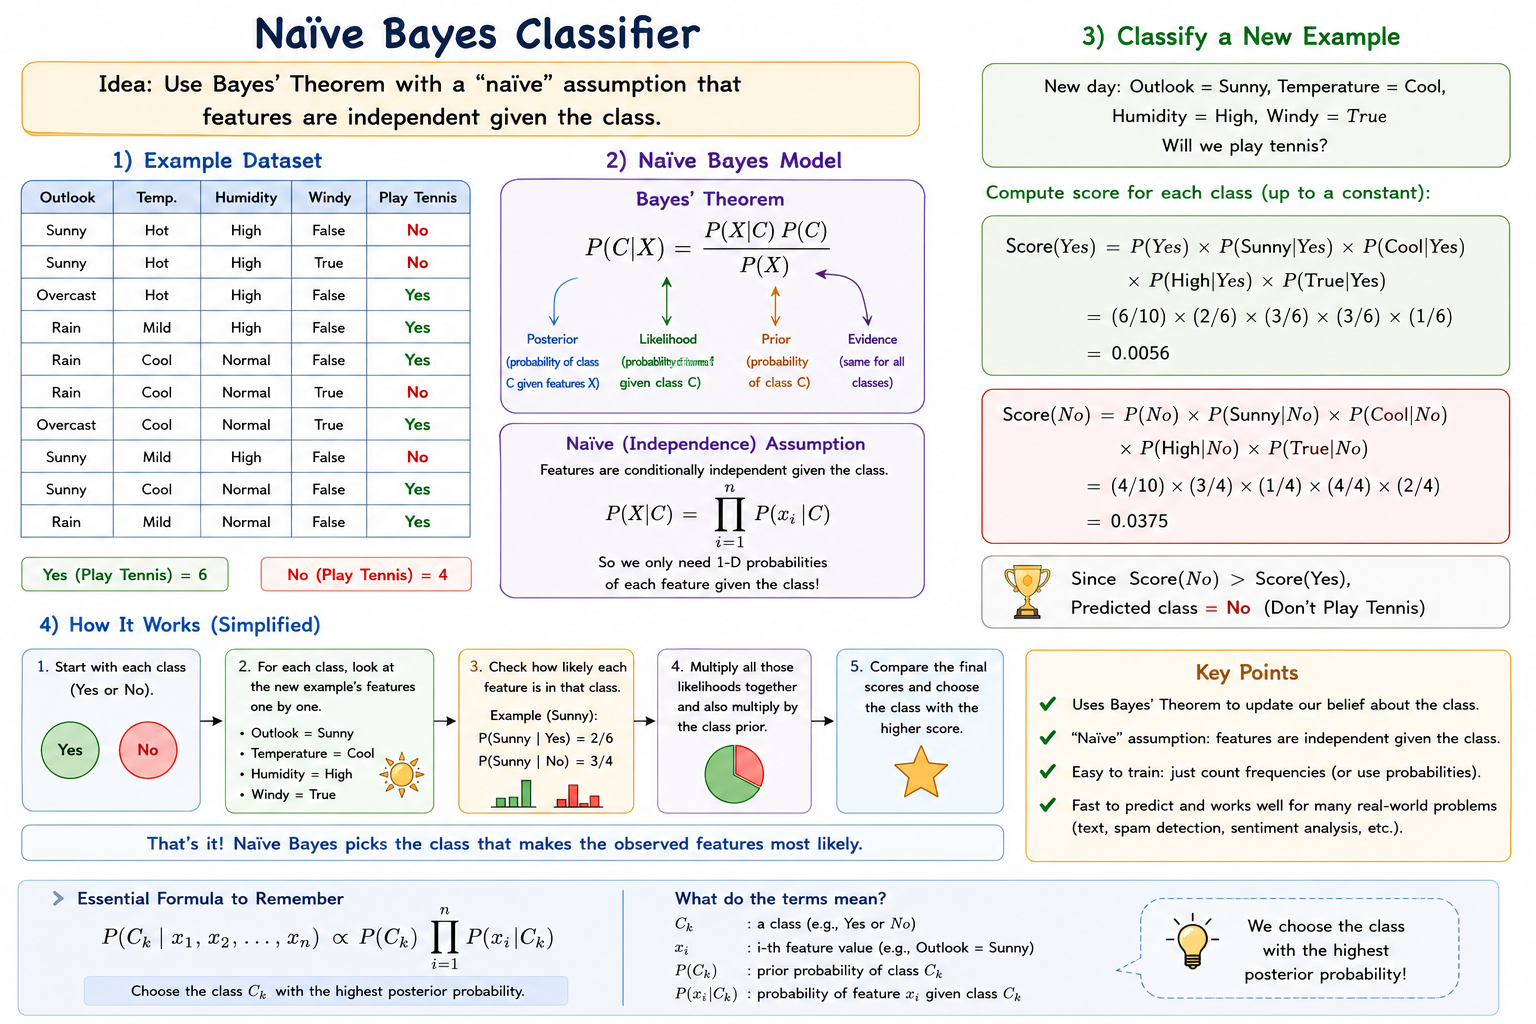


#### **How Multinomial Naïve Bayes Works**

The Multinomial Naïve Bayes classifier is commonly used for text classification and count-based data, such as Bag-of-Words (BoW) features.
In our DNA example, the model uses the counts of k-mers to predict the gene family.

#### **Main Idea**

The classifier learns which words or k-mers appear more frequently in each class.

For example:

- Gene family A may frequently contain:
```text
gtgccc, tgccca
```

- Gene family B may frequently contain:
```text
ccaggt, aggttt
```
When a new sequence is given, the model checks which class is most likely to generate those observed k-mers.

#### **Why is it called "Naïve"?**

The model assumes that all features are independent.

For example, it assumes:

```text
P(word1 AND word2) = P(word1) × P(word2)
```

This assumption is usually not completely true, but the model still performs surprisingly well for many NLP and sequence classification tasks.

#### **How Training Works**

During training, the model counts:

- how often each k-mer appears in each class,
- and how common each class is overall.

For example:

| k-mer | Class A Count | Class B Count |
|---|---|---|
| gtgccc | 50 | 2 |
| ccaggt | 3 | 40 |

The model converts these counts into probabilities.

#### **How Prediction Works**

For a new DNA sequence:

```text
gtgccc tgccca gcccag
```

the model calculates:

$$
P(Class \mid Sequence)
$$

for every gene class.

It estimates:

- how likely the observed k-mers are for each class,
- then selects the class with the highest probability.

#### **Why Multinomial Naïve Bayes Works Well Here**

Multinomial Naïve Bayes is well suited for:

- count-based features,
- sparse Bag-of-Words matrices,
- and high-dimensional text-like data.

Since DNA k-mer counts behave similarly to word counts in NLP, this model provides a fast and effective baseline classifier.



To evaluate the model fairly, we reserve 20% of the human DNA dataset as a test set. The remaining 80% is used to train the classifier.

Use `train_test_split` from `sklearn` to split the dataset.


In [683]:
from sklearn.model_selection import train_test_split

In [ ]:
# Write your solution here
X_train, X_test, y_train, y_test = train_test_split(
    X, y_human, test_size=0.20, random_state=42
)

Next, build a simple multinomial naive Bayes classifier.


In [685]:
from sklearn.naive_bayes import MultinomialNB

In [686]:
# Write your solution here
classifier = MultinomialNB(alpha=0.1)
classifier.fit(X_train, y_train)

,alpha,0.1
,force_alpha,True
,fit_prior,True
,class_prior,None


Finally, we will make predictions on the held out test set, and print out a classification report.


In [687]:
from sklearn.metrics import classification_report

In [ ]:
# Write your solution here
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       102
           1       1.00      0.98      0.99       106
           2       1.00      1.00      1.00        78
           3       0.99      0.99      0.99       125
           4       0.99      0.96      0.98       149
           5       1.00      1.00      1.00        51
           6       0.96      0.99      0.98       265

    accuracy                           0.98       876
   macro avg       0.99      0.99      0.99       876
weighted avg       0.98      0.98      0.98       876



## **Authors**


[Kopal Garg](https://www.linkedin.com/in/gargkopal/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML311Coursera35714171-2022-01-01) is a Masters student in Computer Science at the University of Toronto.

Su Wu


## **Change Log**


| Date (YYYY-MM-DD) | Version | Changed By | Change Description    |
| ----------------- | ------- | ---------- | --------------------- |
| 2022-06-23        | 0.1     | Kopal Garg | Create Lab            |
| 2022-08-02        | 0.2     | Kopal Garg | Added another example |
| 2022-09-07        | 0.2     | Steve Hord | QA pass edits         |
|2026-05-24 | Student modification |Su Wu | Added explanatory documentation, code comments, and minor code edits for coursework, learning, and portfolio development|


Copyright © 2022 IBM Corporation. All rights reserved.
